In [ ]:
import sys
from pathlib import Path

NOTEBOOK_CWD = Path.cwd().resolve()
for candidate in (
    NOTEBOOK_CWD,
    NOTEBOOK_CWD.parent,
    NOTEBOOK_CWD.parent.parent,
):
    src_dir = candidate / "src"
    if src_dir.exists():
        if str(src_dir) not in sys.path:
            sys.path.insert(0, str(src_dir))
        break

from utils.notebook_env import configure_notebook_environment

configure_notebook_environment()

import pandas as pd

from utils.comparison_utils import filter_correct_ostia_cases
from utils.visualization.comparison import plot_dice_distribution_by_subset
from utils.visualization.segmentation_eda import (
    plot_distance_distribution_by_subset,
    plot_status_distribution_by_subset,
    plot_success_error_by_subset,
)

SUCCESS_STATUS = ["ambos toleráveis", "ambos corretos"]
BAD_OSTIA_STATUS = ["óstios não encontrados", "óstios ruins (bloqueado)"]


# Análise Exploratória dos Resultados de Segmentação dos Óstios
Este notebook realiza uma análise exploratória dos resultados da segmentação dos óstios a partir do pipeline. São apresentados gráficos e estatísticas para avaliar a qualidade das segmentações.

## Carregamento dos Dados
Os dados de saída do pipeline são carregados a partir do arquivo CSV gerado, contendo as informações de status e coordenadas dos óstios para cada imagem.

In [2]:
base_path = "../output/segmentation/8.final_results"

# Paths para High Resolution
path_high_train = f"{base_path}/high_res/2026-04-21_08-42-13/ostios_train_summary.csv"
path_high_val = f"{base_path}/high_res/2026-04-21_08-42-13/ostios_val_summary.csv"
path_high_test = f"{base_path}/high_res/2026-04-28_14-28-44/ostios_test_summary.csv"

# Paths para Mid Resolution
path_mid_train = f"{base_path}/mid_res/2026-04-30_14-33-37/ostios_train_summary.csv"
path_mid_val = f"{base_path}/mid_res/2026-04-30_13-24-40/ostios_val_summary.csv"
path_mid_test = f"{base_path}/mid_res/2026-05-02_10-48-13/ostios_test_summary.csv"

# Carregar todos os dados
data = {
    'high': {
        'train': pd.read_csv(path_high_train),
        'val': pd.read_csv(path_high_val),
        'test': pd.read_csv(path_high_test),
    },
    'mid': {
        'train': pd.read_csv(path_mid_train),
        'val': pd.read_csv(path_mid_val),
        'test': pd.read_csv(path_mid_test),
    }
}

# Dataset atualmente ativo (padrão: mid/train)
current_resolution = 'mid'
current_split = 'train'
df = data[current_resolution][current_split]

print("Dados carregados com sucesso!")
print("\nResolução e Split disponíveis: high/train, high/val, high/test, mid/train, mid/val, mid/test")
print(f"Dados ativos: {current_resolution}/{current_split}")
df.head()

Dados carregados com sucesso!

Resolução e Split disponíveis: high/train, high/val, high/test, mid/train, mid/val, mid/test
Dados ativos: mid/train


,IMG_ID,dice_artery,artery_voxels,ostia_found,ostia_status,segmentation_attempted,proceeded_with_bad_ostia,skip_reason,ostia_error,both_correct,...,left_dist_mm,right_dist_mm,ostia_left,ostia_right,error,status,downscale_method,opencv_interpolation,downscale_factors,max_threshold_percentile
0,867,0.351318,17824.0,True,found_but_wrong,True,True,NaN,NaN,False,...,13.620368,1.815066,"(117, 151, 177)","(111, 129, 213)",NaN,nenhum correto,scipy,NaN,"(2, 2, 1)",99.7
1,450,0.000000,0.0,True,found_but_wrong,True,True,NaN,NaN,False,...,62.926010,62.239980,"(45, 121, 270)","(48, 97, 268)",NaN,nenhum correto,scipy,NaN,"(2, 2, 1)",99.7
2,788,0.682574,54960.0,True,both_tolerable,True,False,NaN,NaN,False,...,0.900456,0.636719,"(86, 176, 214)","(118, 153, 247)",NaN,ambos toleráveis,scipy,NaN,"(2, 2, 1)",99.7
3,362,0.637658,27257.0,True,both_tolerable,True,False,NaN,NaN,False,...,0.773438,1.202668,"(101, 165, 185)","(116, 128, 222)",NaN,ambos toleráveis,scipy,NaN,"(2, 2, 1)",99.7
4,10,0.650869,33872.0,True,both_tolerable,True,False,NaN,NaN,False,...,0.994369,0.000000,"(91, 161, 178)","(118, 126, 211)",NaN,ambos toleráveis,scipy,NaN,"(2, 2, 1)",99.7


## Distribuição dos Status de Segmentação

### Treino (Train)

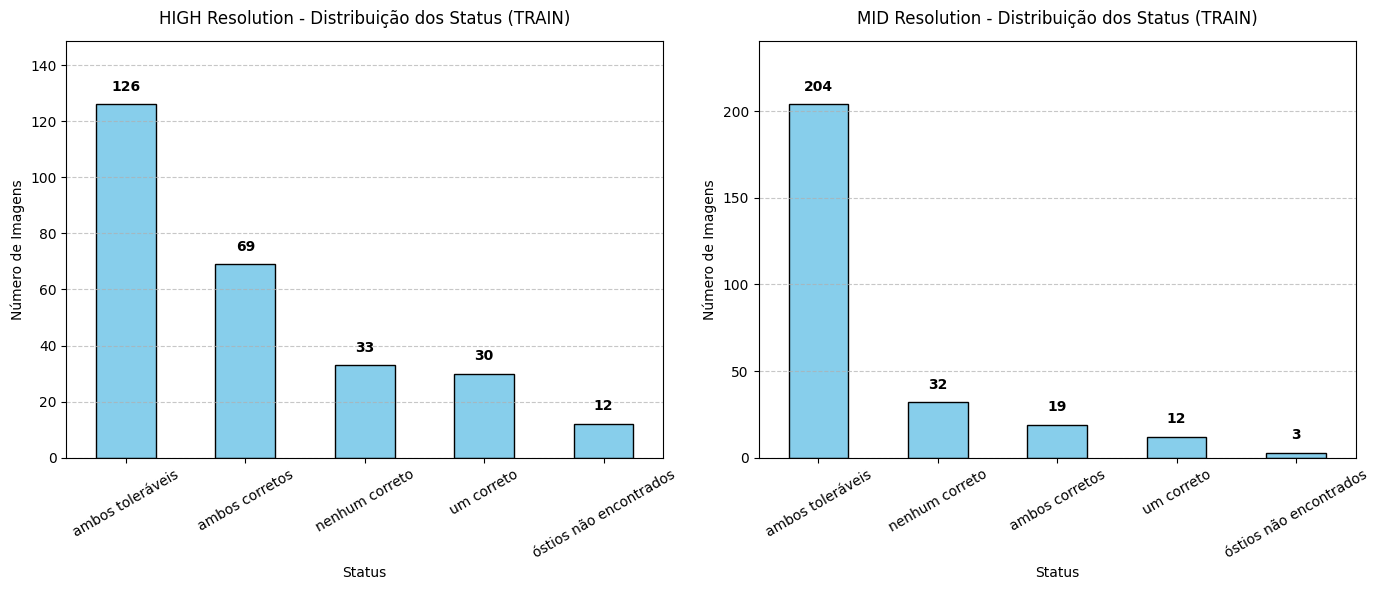

In [3]:
plot_status_distribution_by_subset(data, 'train')

### Validação (Val)

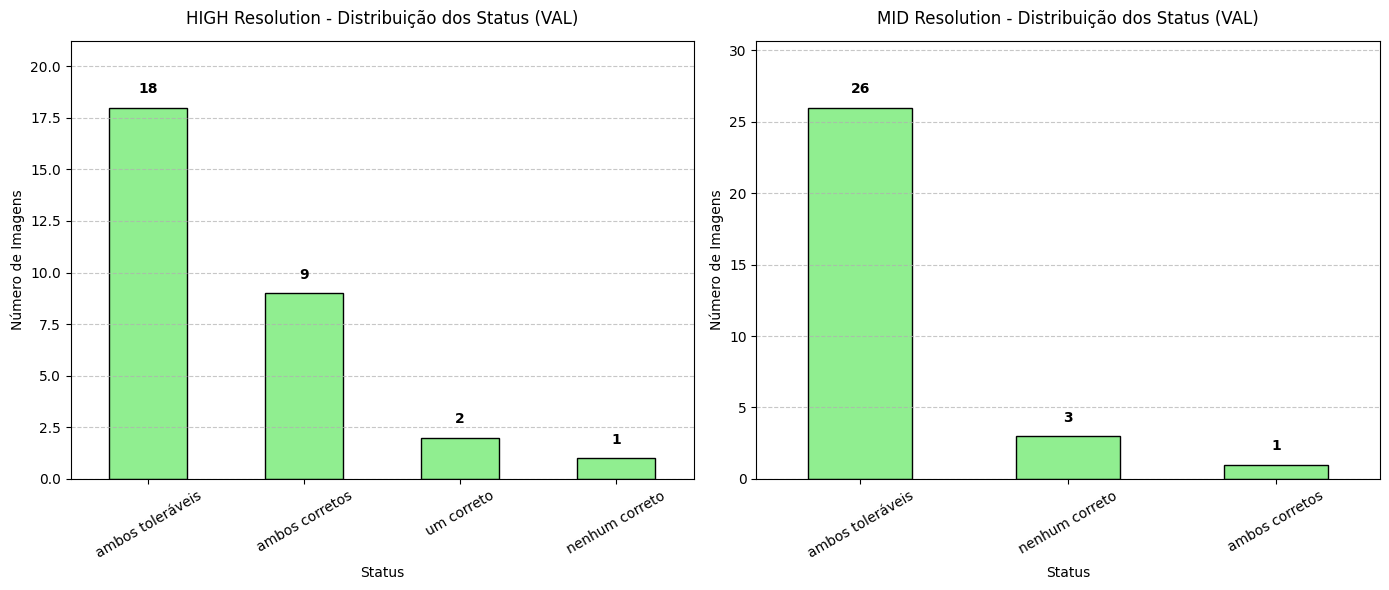

In [4]:
plot_status_distribution_by_subset(data, 'val')

### Teste (Test)

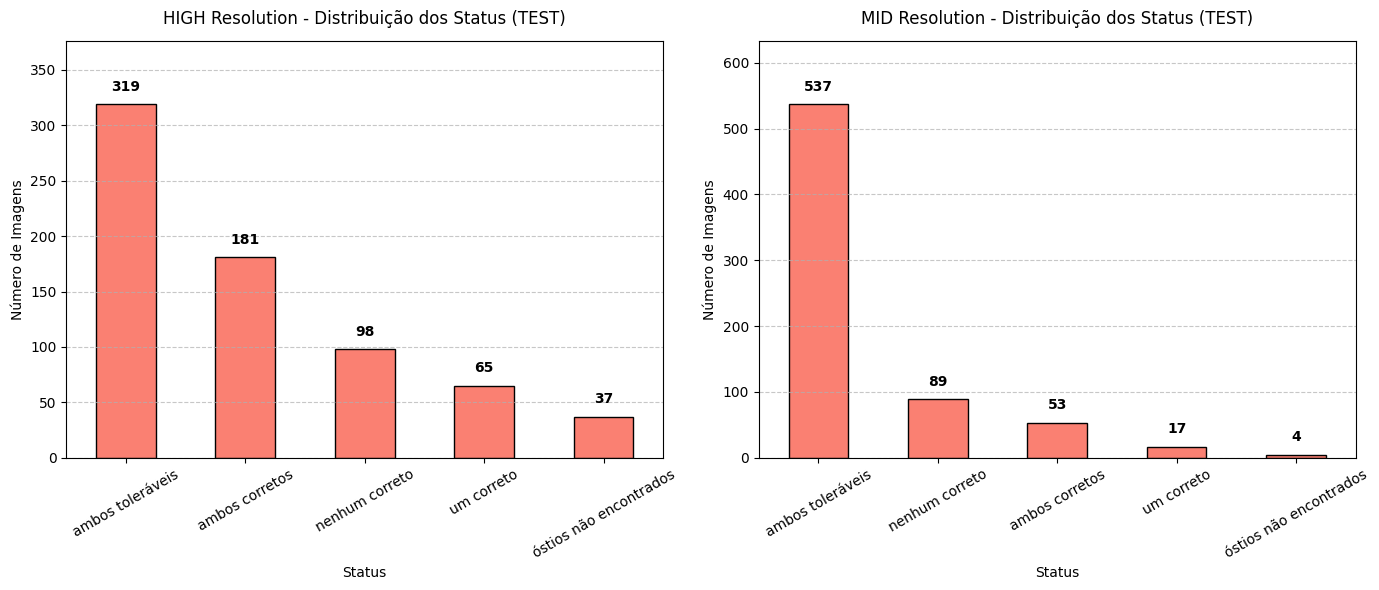

In [5]:
plot_status_distribution_by_subset(data, 'test')

## Acertos e Erros na Segmentação

### Treino (Train)

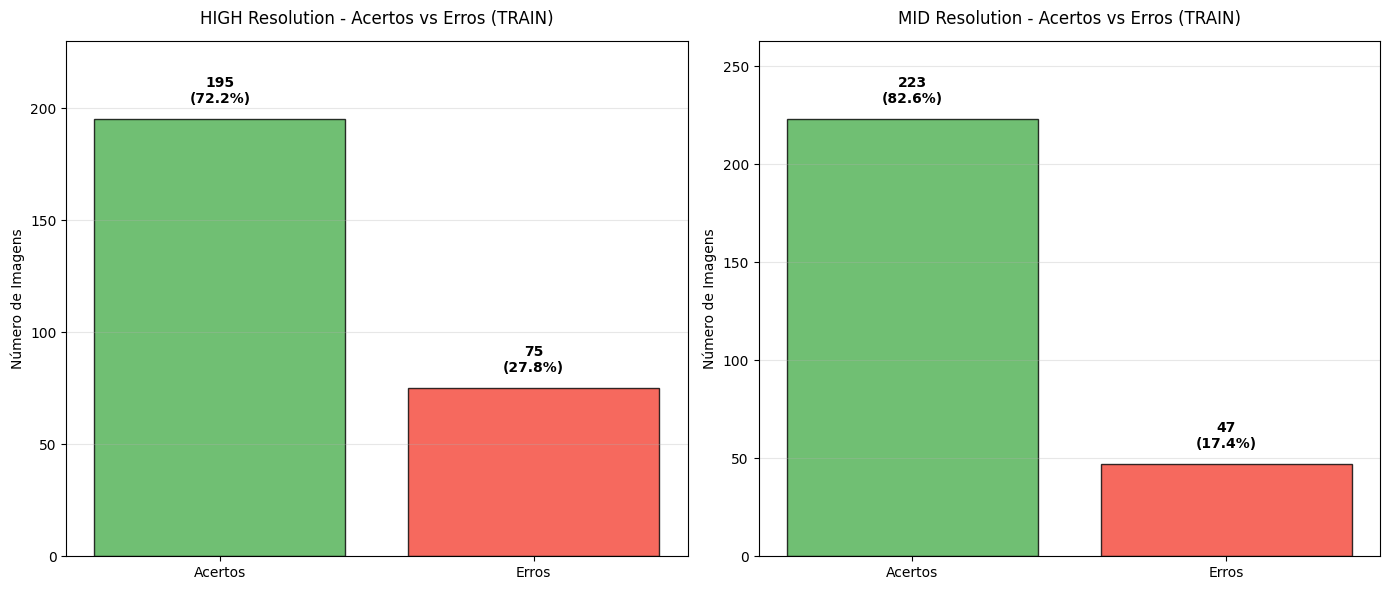

In [6]:
plot_success_error_by_subset(data, 'train', SUCCESS_STATUS)

### Validação (Val)

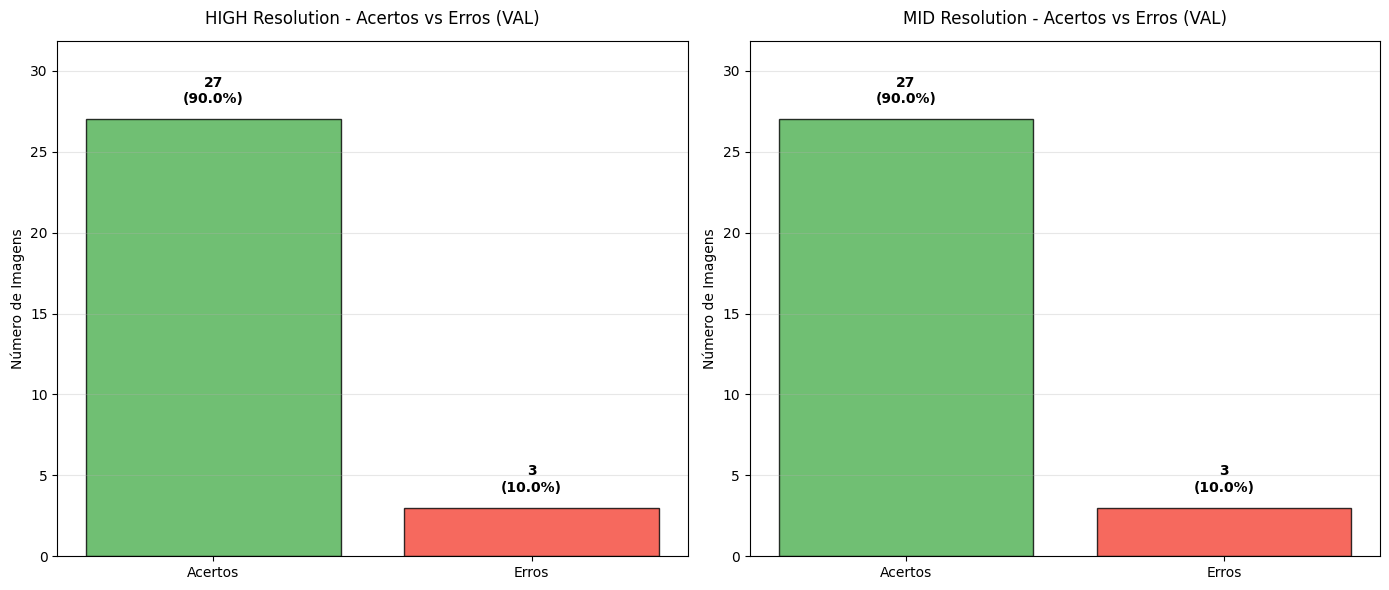

In [7]:
plot_success_error_by_subset(data, 'val', SUCCESS_STATUS)

### Teste (Test)

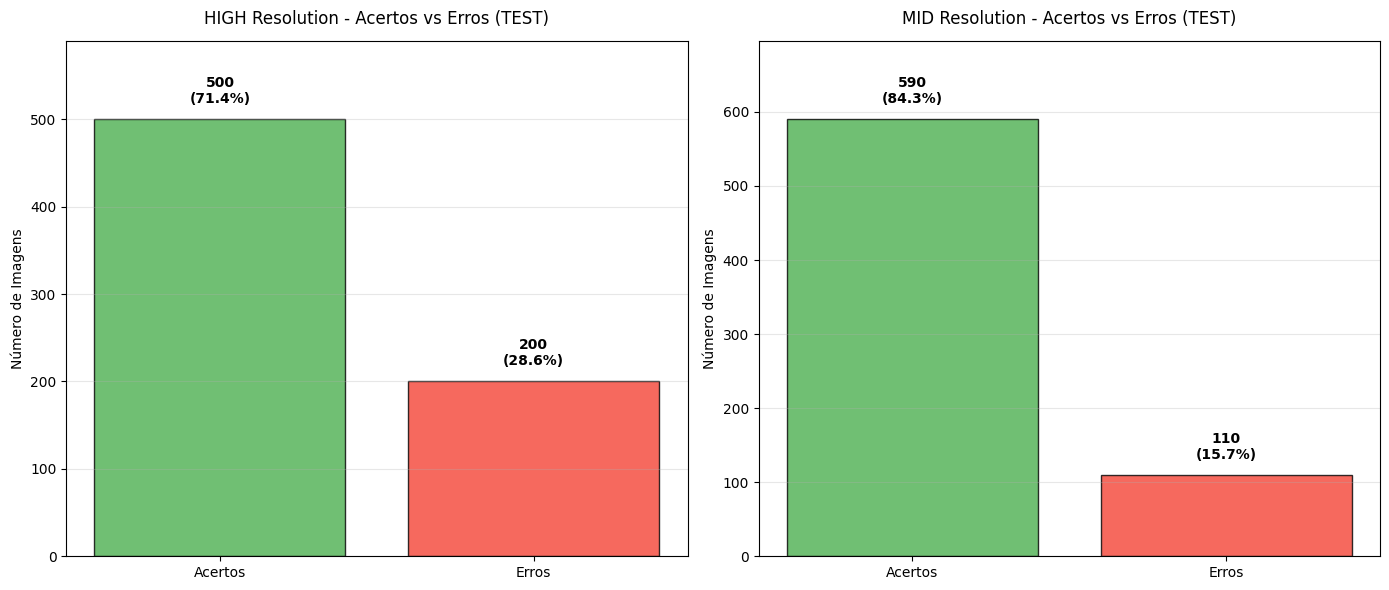

In [8]:
plot_success_error_by_subset(data, 'test', SUCCESS_STATUS)

## Distribuição das Distâncias Left e Right (mm)

A linha tracejada vermelha em **7 mm** representa o limite de tolerância adotado para considerar a detecção do óstio como aceitável.

### Treino (Train)


HIGH - TRAIN
  Left Distance: 227 abaixo de 7.0mm, 31 acima
  Right Distance: 211 abaixo de 7.0mm, 47 acima

MID - TRAIN
  Left Distance: 236 abaixo de 7.0mm, 31 acima
  Right Distance: 243 abaixo de 7.0mm, 24 acima


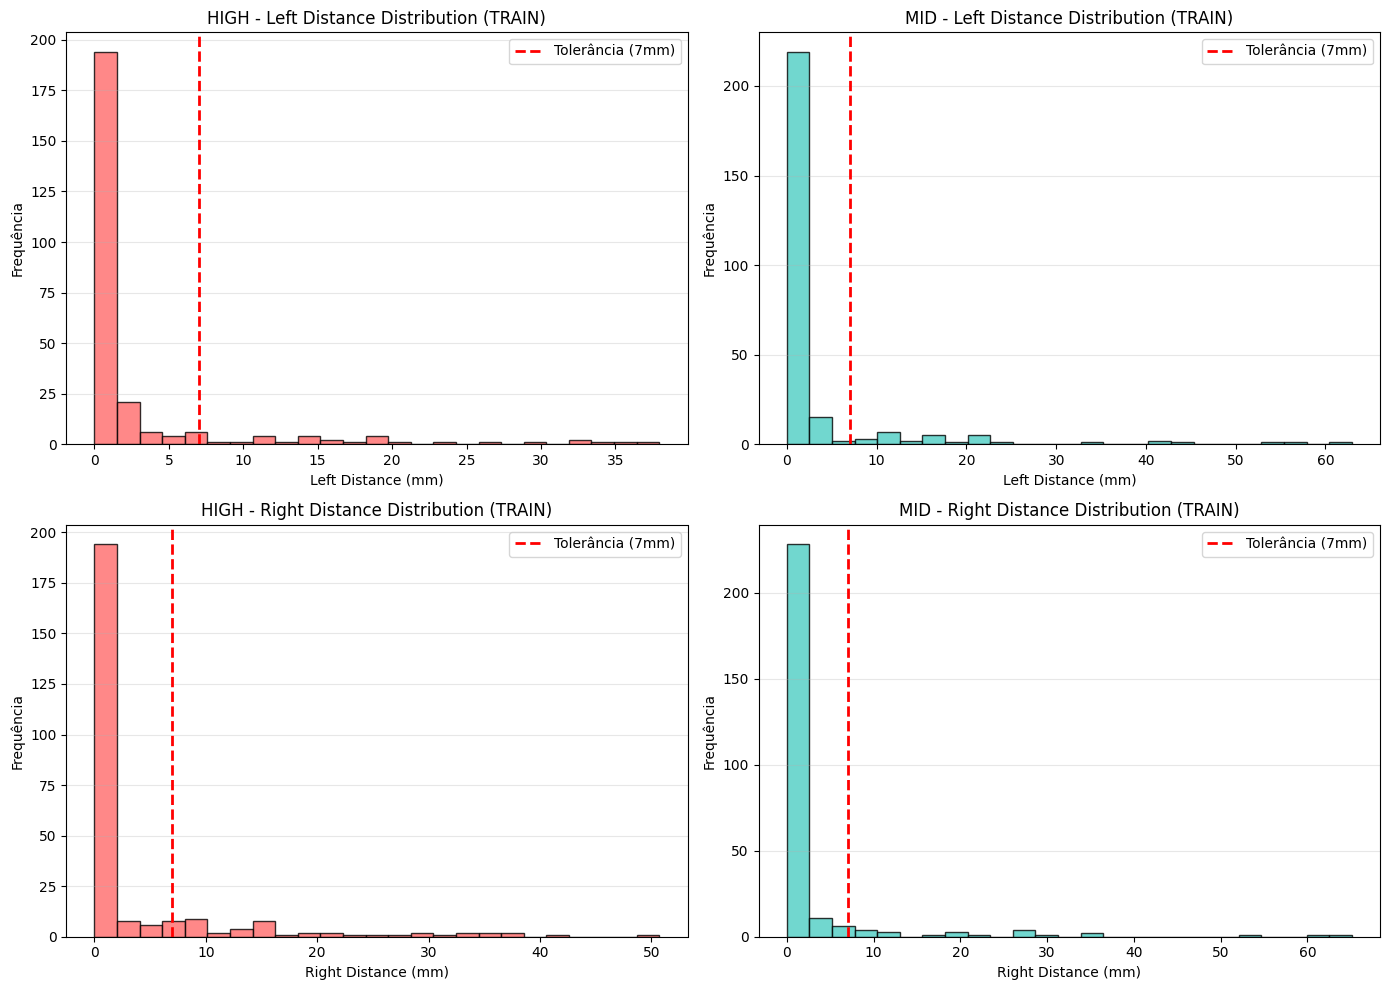

In [9]:
plot_distance_distribution_by_subset(data, 'train', bins=25)

### Validação (Val)


HIGH - VAL
  Left Distance: 29 abaixo de 7.0mm, 1 acima
  Right Distance: 28 abaixo de 7.0mm, 2 acima

MID - VAL
  Left Distance: 28 abaixo de 7.0mm, 2 acima
  Right Distance: 28 abaixo de 7.0mm, 2 acima


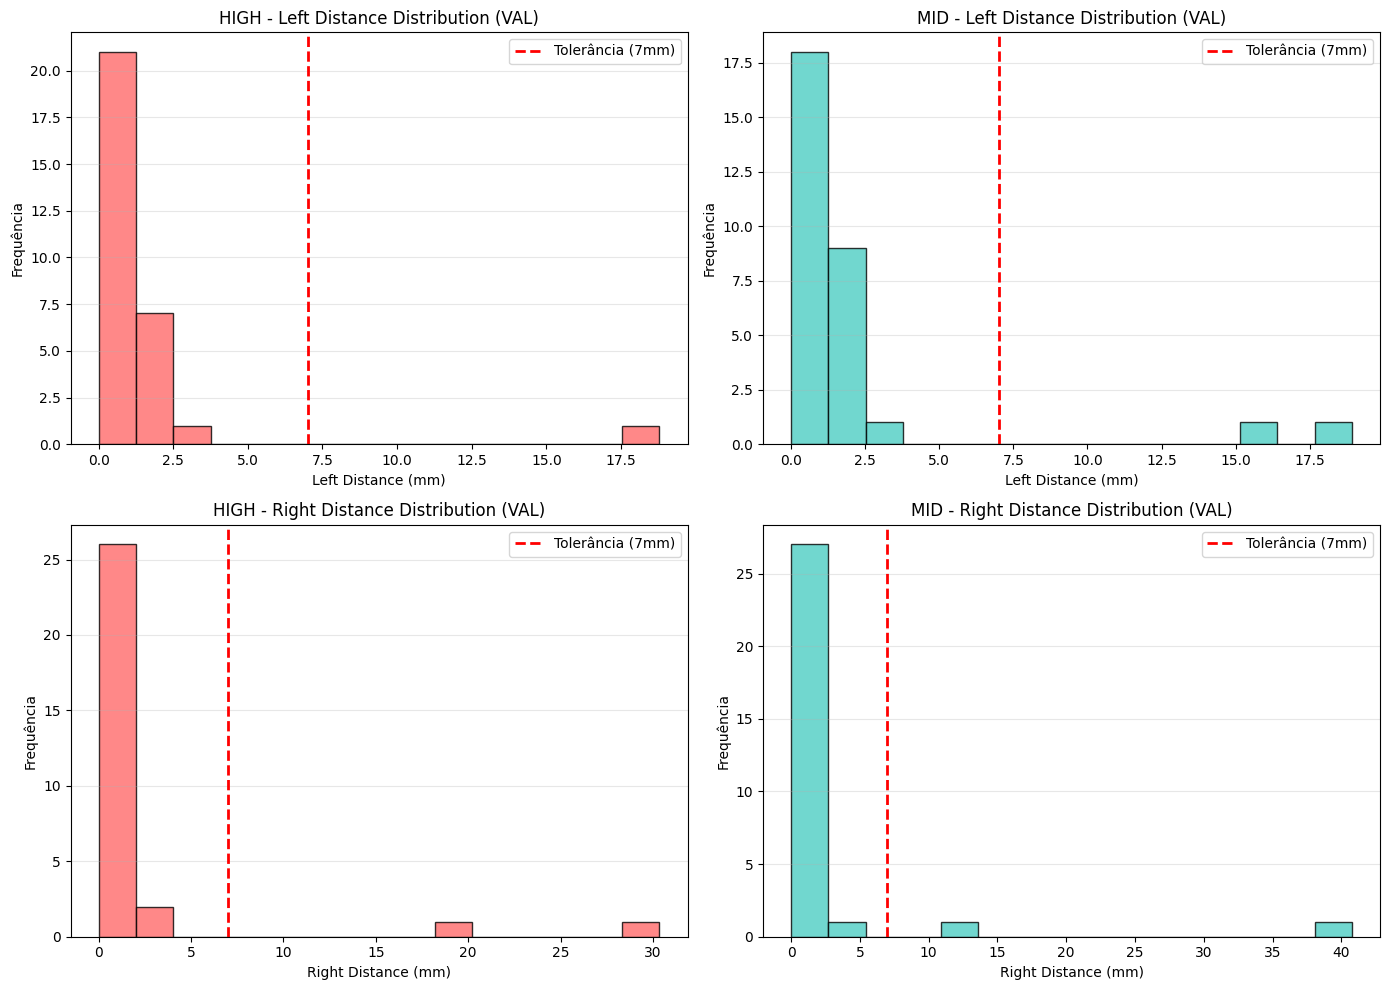

In [10]:
plot_distance_distribution_by_subset(data, 'val', bins=15)

### Teste (Test)


HIGH - TEST
  Left Distance: 574 abaixo de 7.0mm, 89 acima
  Right Distance: 550 abaixo de 7.0mm, 113 acima

MID - TEST
  Left Distance: 616 abaixo de 7.0mm, 80 acima
  Right Distance: 634 abaixo de 7.0mm, 62 acima


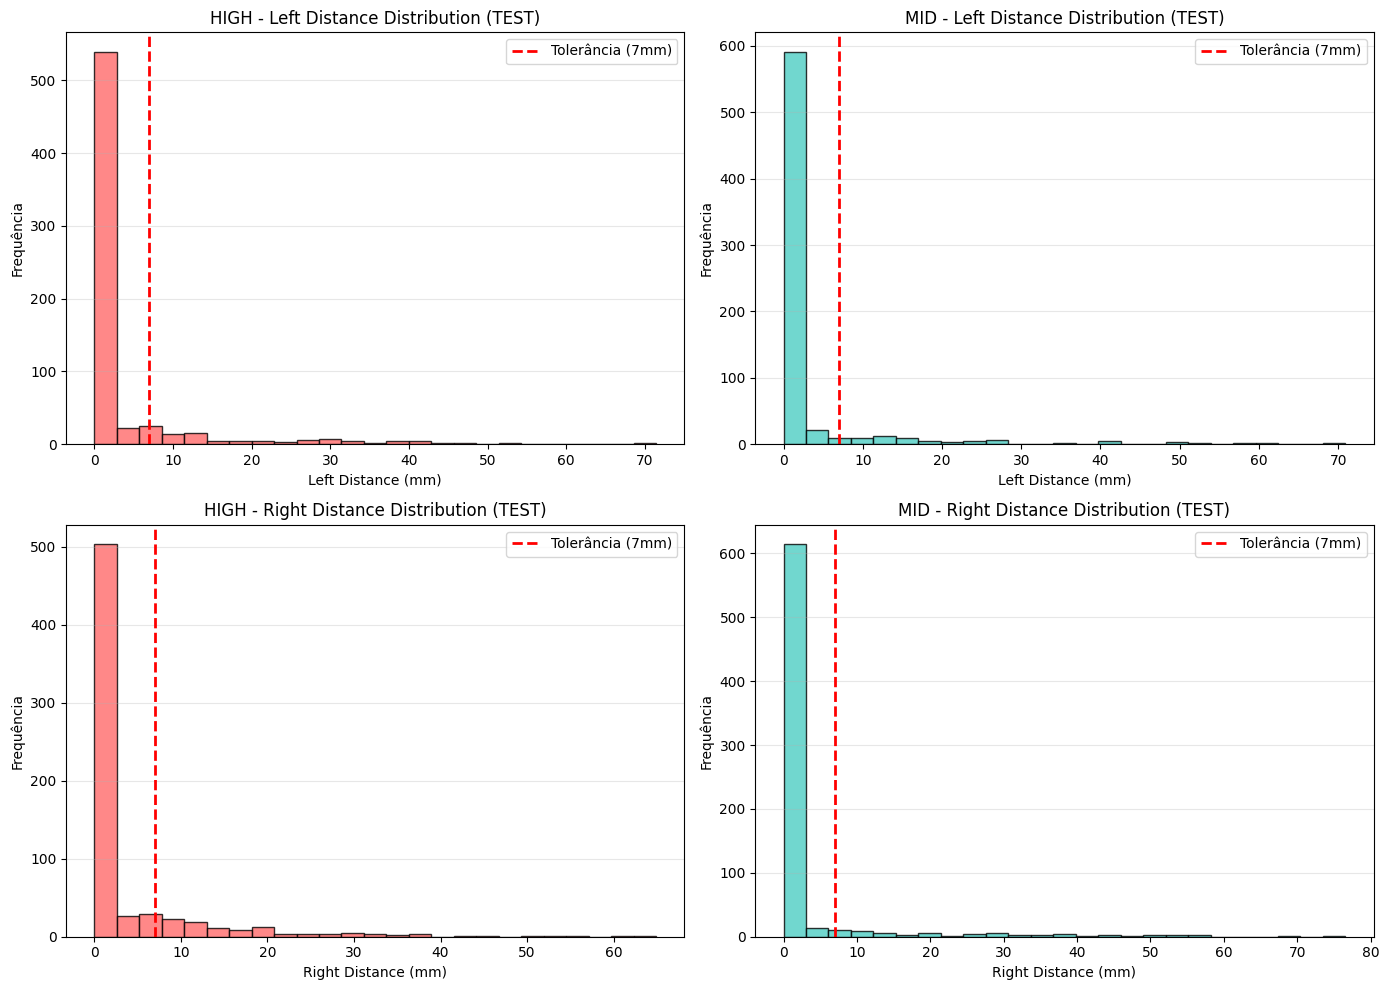

In [11]:
plot_distance_distribution_by_subset(data, 'test', bins=25)

## Distribuição do Dice Score

### Treino (Train)

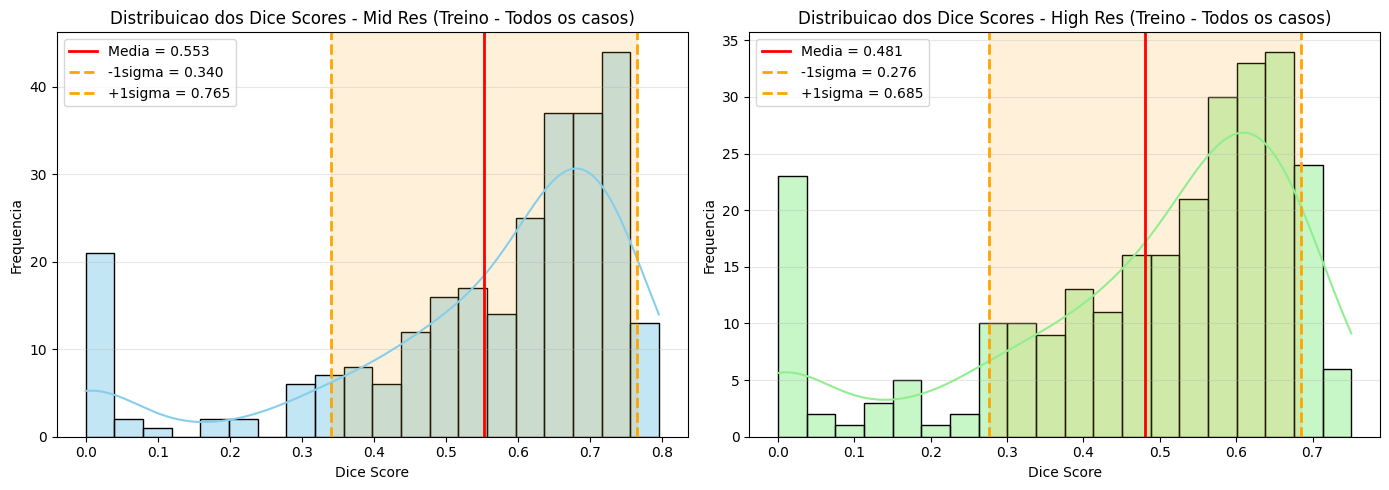

In [12]:
plot_dice_distribution_by_subset(data['mid']['train'], data['high']['train'], "Treino - Todos os casos")

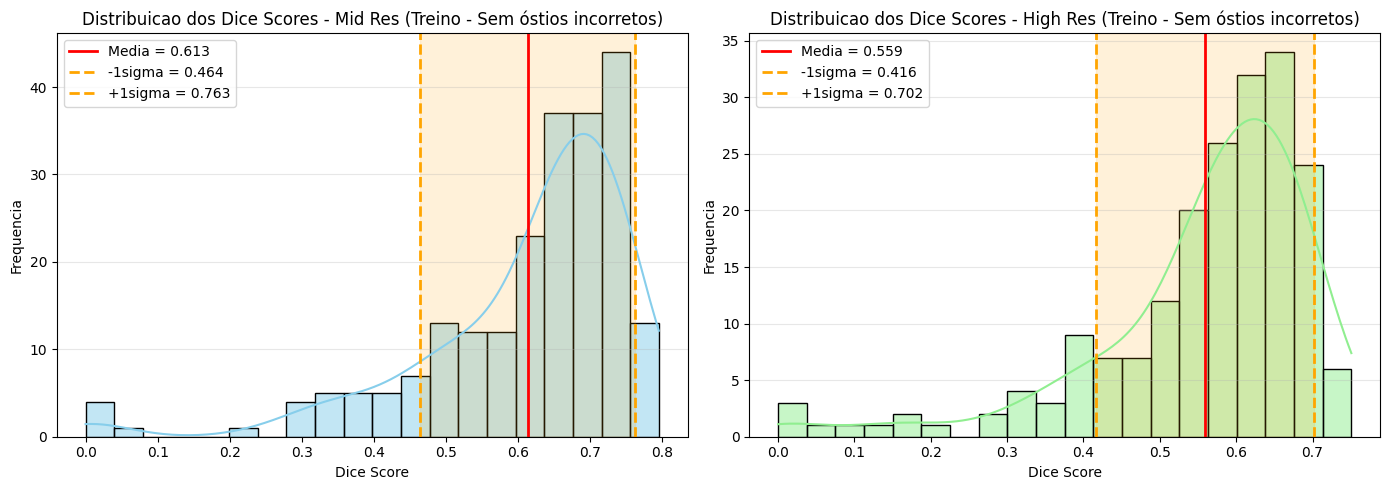

In [13]:
plot_dice_distribution_by_subset(
    filter_correct_ostia_cases(data['mid']['train']),
    filter_correct_ostia_cases(data['high']['train']),
    "Treino - Sem óstios incorretos",
)

### Validação (Val)

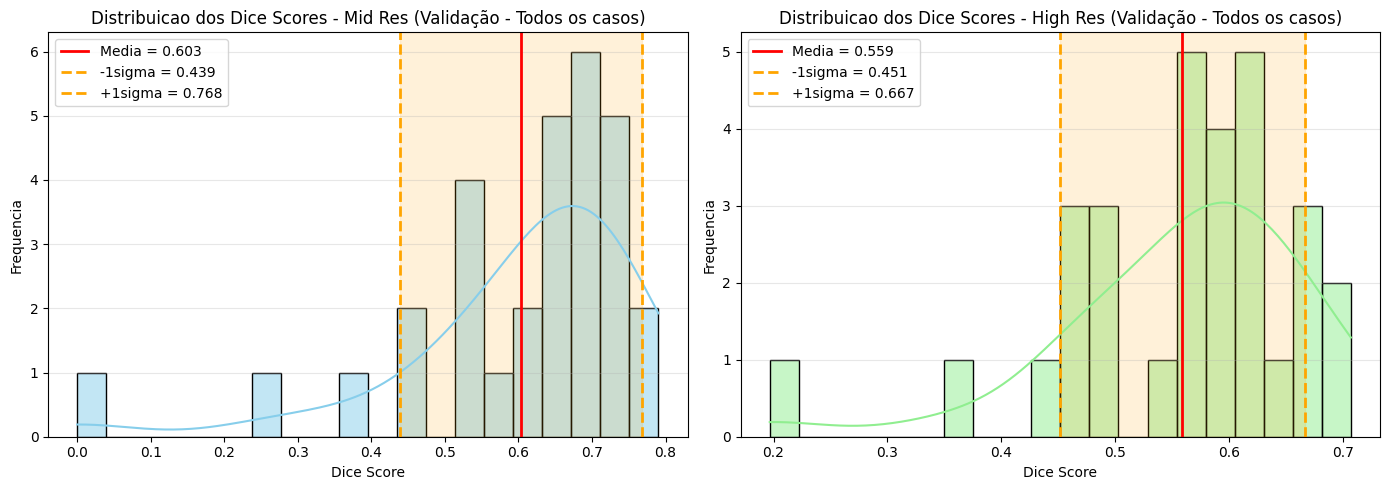

In [14]:
plot_dice_distribution_by_subset(data['mid']['val'], data['high']['val'], "Validação - Todos os casos")

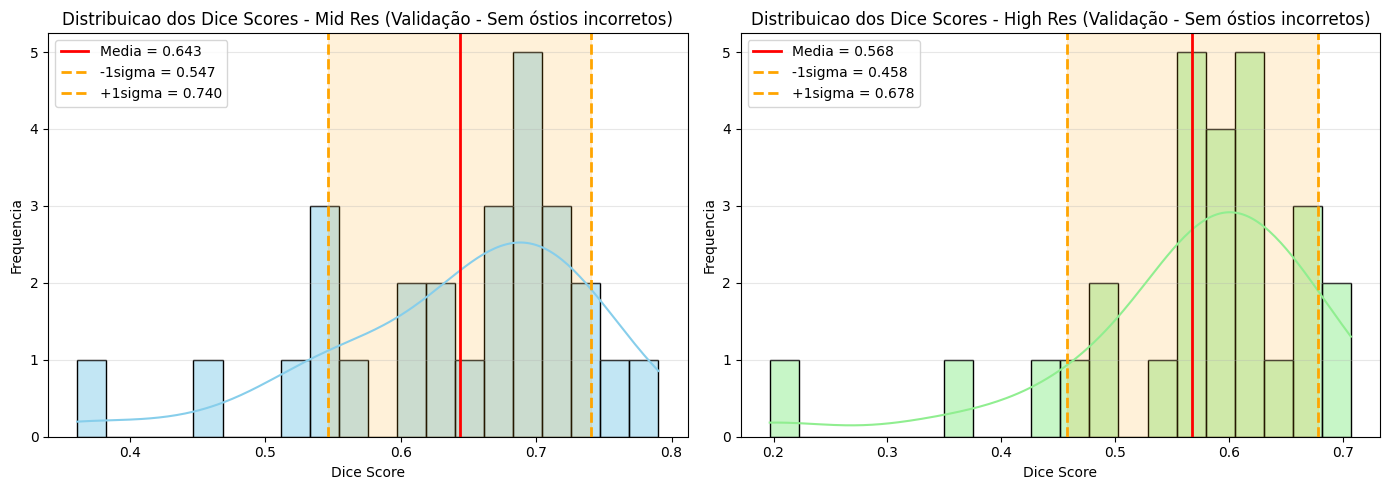

In [15]:
plot_dice_distribution_by_subset(
    filter_correct_ostia_cases(data['mid']['val']),
    filter_correct_ostia_cases(data['high']['val']),
    "Validação - Sem óstios incorretos",
)

### Teste (Test)

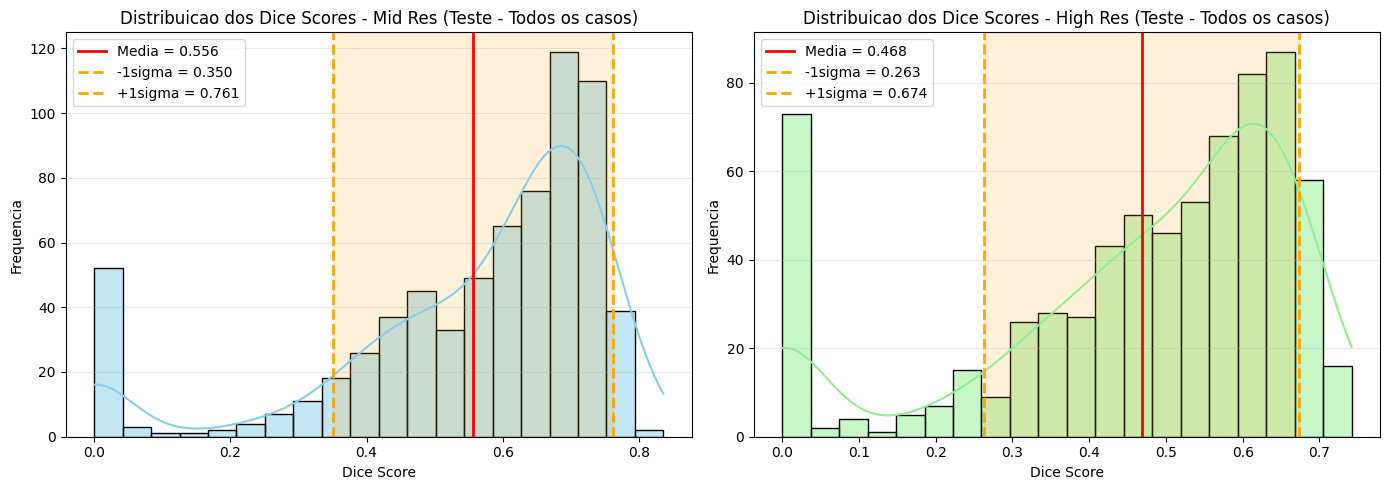

In [16]:
plot_dice_distribution_by_subset(data['mid']['test'], data['high']['test'], "Teste - Todos os casos")

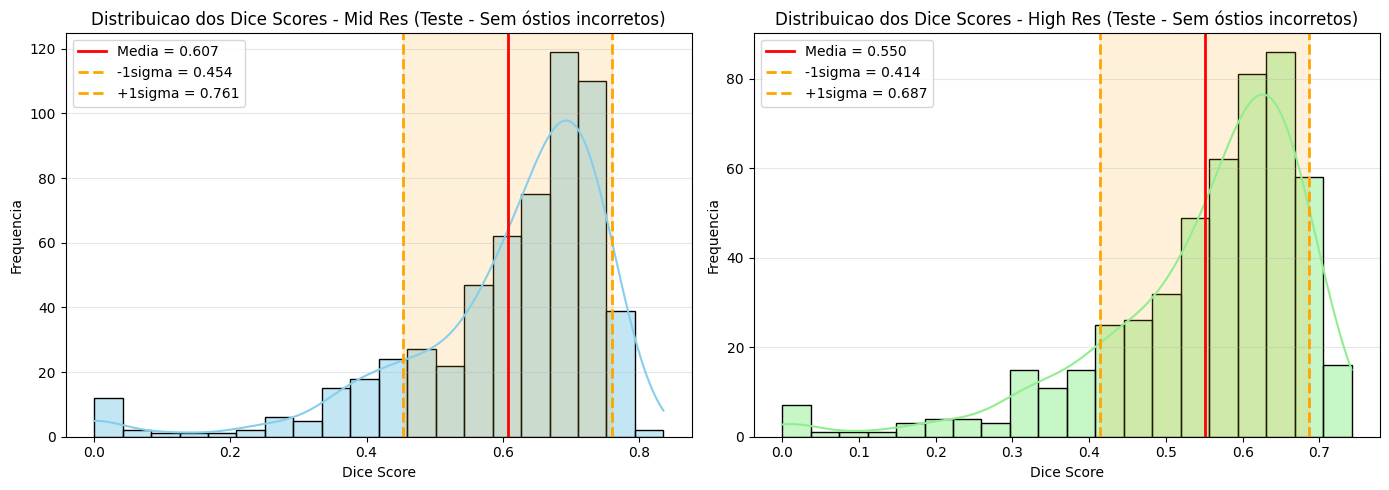

In [17]:
plot_dice_distribution_by_subset(
    filter_correct_ostia_cases(data['mid']['test']),
    filter_correct_ostia_cases(data['high']['test']),
    "Teste - Sem óstios incorretos",
)